# CMAPSS FD001 - Predictive Maintenance Pipeline

**Goal:** end-to-end pipeline that ingests raw test data and produces a per-engine maintenance report combining sensor forecasting, anomaly detection and RUL estimation.

## Pipeline Overview

The pipeline processes raw sensor data through three sequential stages:

- **Stage 1 — Preprocessing**
Raw test data is normalised and enriched with rolling statistics and lag features using the same transformations applied in notebook 02. The scaler is loaded from disk and applied without refitting to prevent data leakage.

- **Stage 2 — Anomaly Detection**
Three complementary signals are combined into a single anomaly score:
  - **Forecast deviation** — residuals between predicted and actual sensor values at t+1, normalised by the per-sensor residual standard deviation from notebook 04
  - **Isolation Forest score** — detects distributional shifts from the healthy operating envelope
  - **Autoencoder reconstruction error** — flags samples poorly reconstructed by the healthy manifold

- **Stage 3 — RUL Forecasting**
The LSTM trained in notebook 03 estimates the remaining useful life at the last
available cycle for each engine.

A final per-engine report combines all signals into a three-level maintenance alert (CRITICAL / WARNING / NORMAL) and is evaluated against ground truth RUL.

## Objectives

- apply all trained models to unseen raw test data
- combine anomaly detection signals into a unified alert
- estimate RUL for each engine at the last available cycle
- evaluate pipeline predictions against ground truth

## Library and Environment setup

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
import os, joblib, sys

import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb

sys.path.append("..")
from src.data_loader import load_train_data
from src.preprocessing import (normalize_sensors, add_rolling_stats,
                                add_lag_features, build_final_dataset)
from src.Predictive_Maintenance_Pipeline import (forecast_anomaly_score,
                                                 isolation_forest_score,
                                                 autoencoder_score,
                                                 combine_anomaly_scores,
                                                 predict_rul,
                                                 make_rul_sequences,
                                                 assign_alert, true_alert,
                                                 dominant_signal)

np.random.seed(42)
tf.random.set_seed(42)

import warnings
warnings.filterwarnings('ignore')

In [46]:
RAW_DIR = '../data/raw/'
OUTPUT_DIR = '../outputs/'
RUL_DIR = '../outputs/RUL_forecasting_model/'
SF_DIR = '../outputs/sensor_forecasting_model/'
AD_DIR = '../outputs/anomaly_detection_model/'
FIG_DIR = '../outputs/figures/'

## Load Raw Test Data

Raw CMAPSS test data is loaded directly from the original files — no preprocessing has been applied at this stage.

`RUL_FD001.txt` contains the ground truth RUL at the last available cycle for each engine, used for final evaluation.

In [47]:
test_df = load_train_data(os.path.join(RAW_DIR, 'test_FD001.txt'))
print(f"Test  : {test_df.shape}  — {test_df.engine_id.nunique()} engines")

Test  : (13096, 26)  — 100 engines


In [48]:
rul_df  = pd.read_csv(os.path.join(RAW_DIR, 'RUL_FD001.txt'),
                      header=None, names=['RUL'])
print(f"RUL GT: {rul_df.shape}")

RUL GT: (100, 1)


In [49]:
test_df.head(3)

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166


In [50]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13096 entries, 0 to 13095
Data columns (total 26 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   engine_id  13096 non-null  int64  
 1   cycle      13096 non-null  int64  
 2   setting_1  13096 non-null  float64
 3   setting_2  13096 non-null  float64
 4   setting_3  13096 non-null  float64
 5   sensor_1   13096 non-null  float64
 6   sensor_2   13096 non-null  float64
 7   sensor_3   13096 non-null  float64
 8   sensor_4   13096 non-null  float64
 9   sensor_5   13096 non-null  float64
 10  sensor_6   13096 non-null  float64
 11  sensor_7   13096 non-null  float64
 12  sensor_8   13096 non-null  float64
 13  sensor_9   13096 non-null  float64
 14  sensor_10  13096 non-null  float64
 15  sensor_11  13096 non-null  float64
 16  sensor_12  13096 non-null  float64
 17  sensor_13  13096 non-null  float64
 18  sensor_14  13096 non-null  float64
 19  sensor_15  13096 non-null  float64
 20  sensor

## Preprocessing

Raw test data is preprocessed using the same pipeline as notebook 02 — the scaler is loaded from disk and applied without refitting to avoid data leakage.

The preprocessing steps are:
1. Drop low-information sensors (same selection from notebook 01)
2. Z-score normalisation using the scaler fitted on `rul_train` in notebook 02
3. Rolling statistics (mean and std, window=5 cycles) per engine
4. Lag features (lag 1, 2, 3) per engine
5. Final feature selection — dropping identifiers and target

The output shape reflects the loss of the first 4 cycles per engine due to the rolling window and lag operations.

In [51]:
scaler = joblib.load(os.path.join(OUTPUT_DIR, 'scaler.pkl'))
selected_sensors = joblib.load(os.path.join(OUTPUT_DIR, 'selected_sensors.pkl'))

In [52]:
sensor_cols_all = [c for c in test_df.columns if c.startswith('sensor')]
sensor_to_drop = [c for c in sensor_cols_all if c not in selected_sensors]

In [53]:
test_df = test_df.drop(columns=sensor_to_drop, errors='ignore')

In [54]:
test_df,_ = normalize_sensors(test_df, scaler=scaler)

In [55]:
test_df = add_rolling_stats(test_df,
                            sensor_cols=selected_sensors,
                            window_size=5)

In [56]:
test_df = add_lag_features(test_df,
                           sensor_cols=selected_sensors,
                           lag_steps=[1, 2, 3])

In [57]:
test_df = build_final_dataset(test_df,
                              identifier_cols=['engine_id', 'cycle'],
                              target_col=[],
                              selected_sensors=selected_sensors)

print(f"Preprocessed test: {test_df.shape}")

Preprocessed test: (12696, 80)


## Load all artifacts

All models and metadata produced by notebooks 03, 04 and 05 are loaded here.
No model is retrained — the pipeline applies trained artifacts to unseen test data.

| Artifact | Source | Description |
|---|---|---|
| `lstm_rul_fd001.keras` | nb03 | Best RUL model — LSTM (RMSE=13.38 on val) |
| `best_models.pkl` | nb04 | Best forecasting model per sensor |
| `{arch}_{sensor}.keras` | nb04 | NN models for sensors where best is TCN/GRU/LSTM |
| `xgb_models.pkl` | nb04 | XGBoost models for sensors where best is XGBoost |
| `residual_std.pkl` | nb04 | Per-sensor residual std — anomaly detection threshold |
| `isolation_forest.pkl` | nb05 | Isolation Forest trained on healthy data |
| `autoencoder.keras` | nb05 | Autoencoder trained on healthy data |

### RUL forecasting

In [58]:
lstm_rul = tf.keras.models.load_model(os.path.join(RUL_DIR,
                                                   'lstm_rul_fd001.keras'))
rul_features = joblib.load(os.path.join(RUL_DIR, 'features.pkl'))
seq_sensors = joblib.load(os.path.join(RUL_DIR, 'seq_sensors.pkl'))
SEQ_LEN_RUL = 30

### Sensor forecasting

In [59]:
best_models = joblib.load(os.path.join(SF_DIR, 'best_models.pkl'))
sf_sensors = joblib.load(os.path.join(SF_DIR, 'sensors.pkl'))
sf_features = joblib.load(os.path.join(SF_DIR, 'features.pkl'))

SEQ_LEN_SF = 30

In [60]:
train_means = joblib.load(os.path.join(SF_DIR, 'train_means.pkl'))
residual_std = joblib.load(os.path.join(SF_DIR, 'residual_std.pkl'))
xgb_models = joblib.load(os.path.join(SF_DIR, 'xgb_models.pkl'))

nn_registry = {}
for s, m in best_models.items():
    if m in ('TCN', 'GRU', 'LSTM'):
        path = os.path.join(SF_DIR, f'{m}_{s}.keras')
        nn_registry[s] = tf.keras.models.load_model(path, safe_mode=False)
        print(f"Loaded: {m}_{s}.keras")

Loaded: LSTM_sensor_2.keras
Loaded: TCN_sensor_3.keras
Loaded: LSTM_sensor_4.keras
Loaded: TCN_sensor_7.keras
Loaded: TCN_sensor_12.keras
Loaded: TCN_sensor_15.keras
Loaded: TCN_sensor_17.keras
Loaded: GRU_sensor_20.keras
Loaded: TCN_sensor_21.keras


### Anomaly detection

In [61]:
iso_forest = joblib.load(os.path.join(AD_DIR, 'isolation_forest.pkl'))
if_threshold = joblib.load(os.path.join(AD_DIR, 'if_threshold.pkl'))
model_ae = tf.keras.models.load_model(os.path.join(AD_DIR, 'autoencoder.keras'))
ae_threshold = joblib.load(os.path.join(AD_DIR, 'ae_threshold.pkl'))
features_ae = joblib.load(os.path.join(AD_DIR, 'features_ae.pkl'))

## Sensor Forecasting & Forecast-based Anomaly Detection



Each sensor is forecast one step ahead using the best model selected in notebook 04 (TCN, GRU, LSTM, XGBoost or Persistence). The normalised residual between the predicted and actual value at t+1 is used as a per-sensor anomaly signal:

$$\text{norm_resid}_s = \frac{|\hat{x}_{s,t+1} - x_{s,t+1}|}{\sigma_s}$$

where $\sigma_s$ is the residual standard deviation of the best model on the validation set (computed in notebook 04).
The **forecast anomaly score** is the mean of the normalised residuals across all 13 sensors — values significantly above 1.0 indicate that the engine is deviating from its expected sensor trajectory.

Sequences are computed once (`make_sf_sequences`) and shared across all sensors
to avoid redundant computation.

In [62]:
print("Computing forecast anomaly scores...")
forecast_scores_df = forecast_anomaly_score(df = test_df,
                                            best_models  = best_models,
                                            nn_registry = nn_registry,
                                            xgb_models = xgb_models,
                                            sf_sensors = sf_sensors,
                                            sf_features = sf_features,
                                            residual_std = residual_std,
                                            seq_len = SEQ_LEN_SF,
                                            train_means = train_means)
print(f"Forecast scores computed: {forecast_scores_df.shape}\n")
print(forecast_scores_df.describe().round(3))

Computing forecast anomaly scores...
Forecast scores computed: (9798, 3)

       engine_id     cycle  forecast_score
count   9798.000  9798.000        9699.000
mean      51.885    96.981           0.739
std       28.090    46.052           0.159
min        2.000    34.000           0.270
25%       29.000    60.000           0.629
50%       52.000    89.000           0.728
75%       76.000   126.000           0.842
max      100.000   303.000           1.462


**Observations:**
The forecast score distribution is right-skewed with a mean of 0.74 and a maximum of 1.46, indicating that some engine cycles deviate up to 1.5 standard deviations from the expected sensor trajectory.  
The 99 missing values (9798 vs 9699 non-null) correspond to the last available
cycle of each engine where a t+1 value exists — one engine was skipped entirely
due to insufficient cycles (< SEQ_LEN), accounting for the difference from the
expected 100.

## Distribution-based Anomaly Detection & Combined Score

Two additional anomaly signals complement the forecast deviation:

- **Isolation Forest** scores each cycle by how easily it can be isolated from the healthy distribution — anomalous cycles require fewer random splits to be separated.  
Score = `-score_samples` (higher = more anomalous).

- **Autoencoder** measures the MSE reconstruction error. Healthy cycles are
reconstructed accurately (low error), while degraded cycles produce higher errors as they fall outside the learned healthy manifold.

The three signals are combined into a single **anomaly score** via weighted average after min-max normalisation to a common [0, 1] scale:

$$\text{anomaly_score} = 0.4 \cdot \text{forecast_norm} + 0.4 \cdot \text{IF_norm} + 0.2 \cdot \text{AE_norm}$$

Weights reflect the relative performance from notebook 05:
- Isolation Forest (AUC=0.807) and forecast deviation are the most reliable signals;
- the Autoencoder (AUC=0.751) contributes with lower weight due to its conservative behaviour.

The per-engine score is computed as the mean over the last `SEQ_LEN` cycles
to reduce noise and produce a stable summary statistic.

In [63]:
print("Computing Isolation Forest scores...")
if_scores_df = isolation_forest_score(test_df, iso_forest, sf_sensors)

print("Computing Autoencoder scores...")
ae_scores_df = autoencoder_score(test_df, model_ae, features_ae)

print("Combining anomaly scores...")
anomaly_df = combine_anomaly_scores(
    forecast_scores_df = forecast_scores_df,
    if_scores_df       = if_scores_df,
    ae_scores_df       = ae_scores_df,
    w_forecast         = 0.4,
    w_if               = 0.4,
    w_ae               = 0.2
)

print(f"Combined anomaly scores: {anomaly_df.shape}\n")
print(anomaly_df.describe().round(3))

Computing Isolation Forest scores...
Computing Autoencoder scores...
Combining anomaly scores...
Combined anomaly scores: (9798, 6)

       engine_id     cycle  forecast_score  if_score  ae_score  anomaly_score
count   9798.000  9798.000        9699.000  9798.000  9798.000       9699.000
mean      51.885    96.981           0.739     0.467     0.199          0.264
std       28.090    46.052           0.159     0.058     0.223          0.092
min        2.000    34.000           0.270     0.379     0.068          0.037
25%       29.000    60.000           0.629     0.428     0.136          0.200
50%       52.000    89.000           0.728     0.451     0.160          0.250
75%       76.000   126.000           0.842     0.487     0.192          0.309
max      100.000   303.000           1.462     0.727     4.457          0.760


In [64]:
anomaly_per_engine = (anomaly_df.sort_values(['engine_id', 'cycle'])
                                .groupby('engine_id')
                                .apply(lambda g: g.tail(SEQ_LEN_SF)[
                                    ['forecast_score',
                                     'if_score',
                                     'ae_score',
                                     'anomaly_score']].mean())
                                .reset_index())

print(f"Anomaly score per engine: {anomaly_per_engine.shape}\n")
print(anomaly_per_engine[['anomaly_score']].describe().round(3))

Anomaly score per engine: (99, 5)

       anomaly_score
count         98.000
mean           0.304
std            0.098
min            0.195
25%            0.229
50%            0.263
75%            0.349
max            0.545


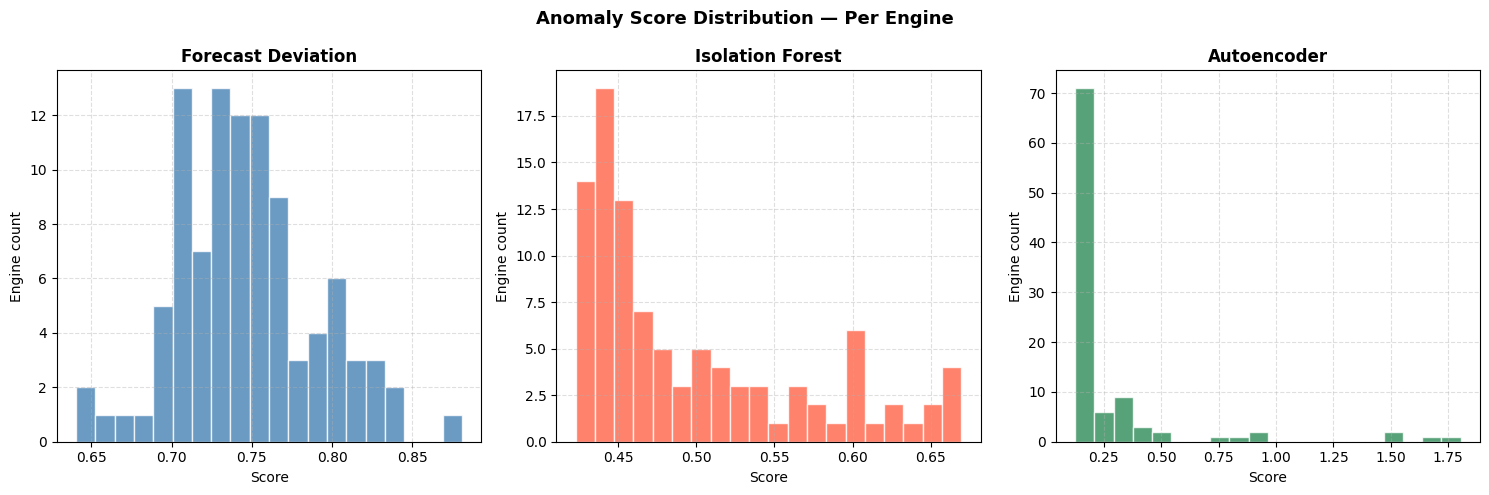

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

score_cols = [('forecast_score', 'Forecast Deviation', 'steelblue'),
              ('if_score', 'Isolation Forest', 'tomato'),
              ('ae_score', 'Autoencoder', 'seagreen')]

for ax, (col, label, color) in zip(axes, score_cols):
    ax.hist(anomaly_per_engine[col], bins=20,
            color=color, edgecolor='white', alpha=0.8)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Score')
    ax.set_ylabel('Engine count')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Anomaly Score Distribution — Per Engine',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '06_anomaly_score_distribution.png'),
            bbox_inches='tight')
plt.show()

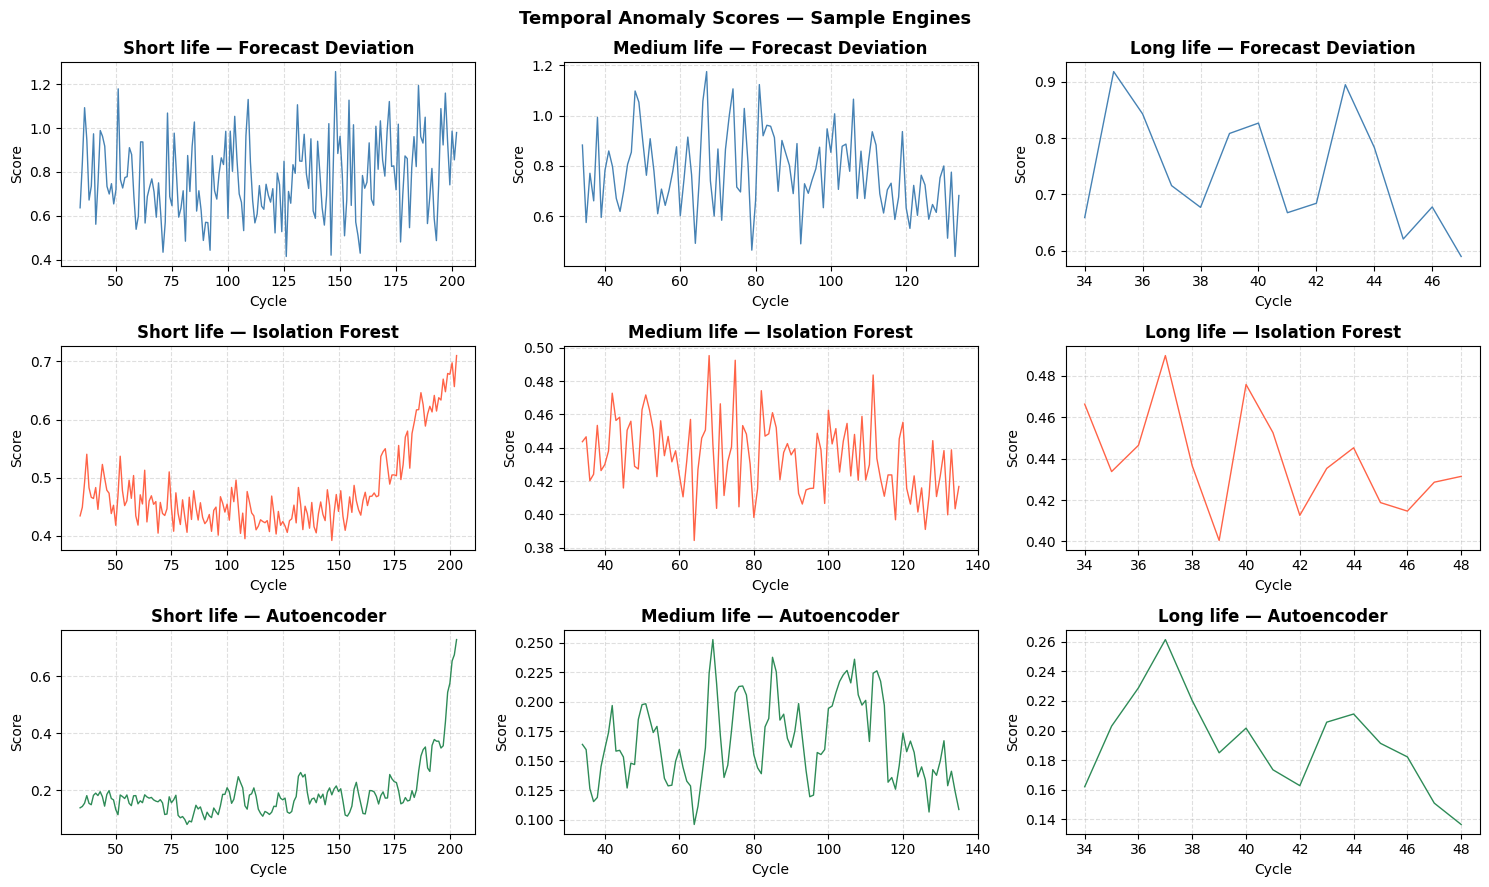

In [66]:
# ── Temporal anomaly visualization — 3 engine sample
rul_gt_series = rul_df['RUL'].values
engine_ids = test_df['engine_id'].unique()

# short / medium / long life based on RUL ground truth
sorted_idx = np.argsort(rul_gt_series)
n = len(sorted_idx)
sample_ids = {'Short life' : engine_ids[sorted_idx[0]],
              'Medium life': engine_ids[sorted_idx[n // 2]],
              'Long life' : engine_ids[sorted_idx[-1]]}

fig, axes = plt.subplots(3, 3, figsize=(15, 9), sharey=False)

for col_idx, (life_label, eng_id) in enumerate(sample_ids.items()):
    eng_scores = (anomaly_df[anomaly_df['engine_id'] == eng_id]
                  .sort_values('cycle'))

    for row_idx, (col, label, color) in enumerate(score_cols):
        ax = axes[row_idx, col_idx]
        ax.plot(eng_scores['cycle'], eng_scores[col],
                color=color, linewidth=1)
        ax.set_title(f'{life_label} — {label}', fontweight='bold')
        ax.set_xlabel('Cycle')
        ax.set_ylabel('Score')
        ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Temporal Anomaly Scores — Sample Engines',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '06_temporal_anomaly_scores.png'),
            bbox_inches='tight')
plt.show()

**Observations — Anomaly Score Distribution:**
Forecast deviation scores cluster between 0.65–0.85, reflecting moderate but
consistent deviations from the expected sensor trajectories across the test fleet.  
Isolation Forest scores show a bimodal distribution: a main cluster around 0.45–0.50 (healthier engines) and a right tail above 0.55 (more degraded engines).  
Autoencoder scores are heavily right-skewed with occasional spikes up to 1.75 — consistent with its behaviour as a late-stage anomaly detector.

**Observations — Temporal Anomaly Scores:**
All three signals show higher variability on the short-life engine, consistent with its advanced degradation state.  
The Isolation Forest signal increases most monotonically with cycle count, confirming its ability to track distributional drift over time.  
The forecast deviation captures cycle-to-cycle oscillations, producing a noisier but more responsive signal.  
The Autoencoder remains low for most of the engine's life and rises steeply only in the final cycles.

## RUL Forecasting

The LSTM trained in notebook 03 (RMSE=13.38, R²=0.898 on the validation set)
is applied to the test set.  
For each engine, the prediction at the **last available cycle** is used as the RUL estimate.

The LSTM requires sequences of length 30 — engines with fewer than 30 cycles cannot produce a sequence and fall back to `RUL_cap/2 = 62.5` as a conservative
estimate.  
The predicted RUL is clipped to [0, 125] to match the training cap applied in notebook 02.

In [67]:
print("Computing RUL predictions...")
rul_pred_df = predict_rul(df = test_df,
                          lstm_rul = lstm_rul,
                          seq_sensors = seq_sensors,
                          rul_features = rul_features,
                          seq_len = SEQ_LEN_RUL,
                          rul_cap = 125)

# Adds ground truth for valuation
rul_pred_df['RUL_true'] = rul_df['RUL'].values
rul_pred_df['error'] = rul_pred_df['RUL_true'] - rul_pred_df['RUL_pred']
rul_pred_df['abs_error'] = rul_pred_df['error'].abs()

rmse = np.sqrt((rul_pred_df['error'] ** 2).mean())
mae  = rul_pred_df['abs_error'].mean()

print(f"\nRUL Forecasting — Test Set")
print(f"  RMSE : {rmse:.2f} cycles")
print(f"  MAE  : {mae:.2f}  cycles")
print(f"  RUL_pred range: [{rul_pred_df['RUL_pred'].min():.1f}, "
      f"{rul_pred_df['RUL_pred'].max():.1f}]")
print(f"  RUL_true range: [{rul_pred_df['RUL_true'].min():.1f}, "
      f"{rul_pred_df['RUL_true'].max():.1f}]")

Computing RUL predictions...

RUL Forecasting — Test Set
  RMSE : 17.62 cycles
  MAE  : 12.51  cycles
  RUL_pred range: [7.7, 123.3]
  RUL_true range: [7.0, 145.0]


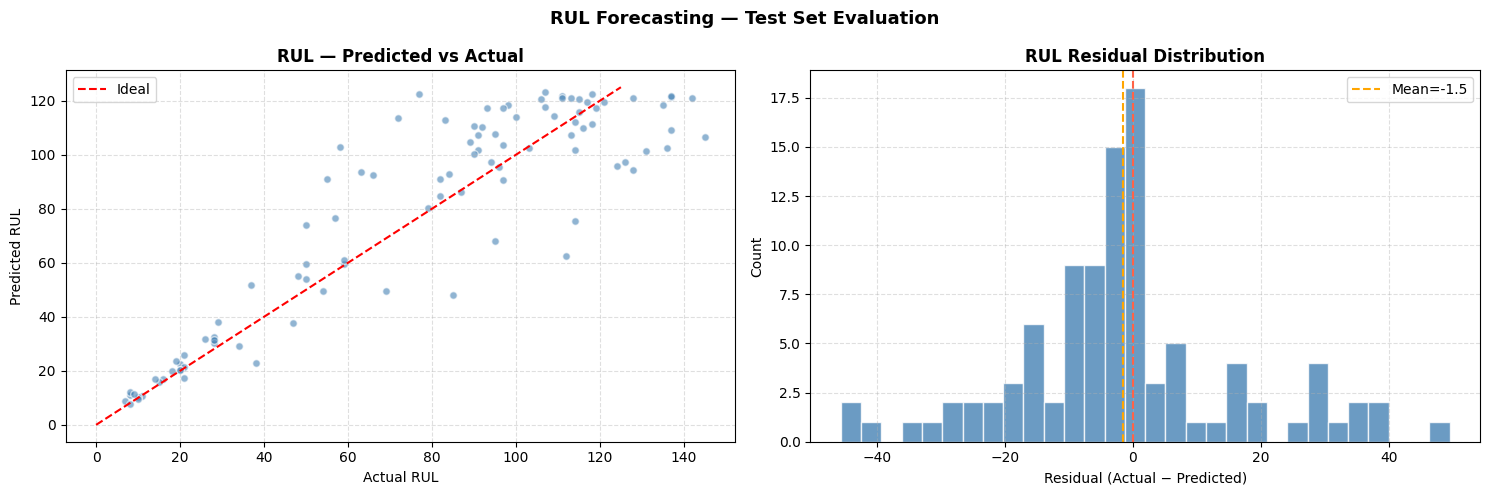

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter predicted vs actual
axes[0].scatter(rul_pred_df['RUL_true'],
                rul_pred_df['RUL_pred'],
                alpha=0.6, s=30, color='steelblue', edgecolors='white')
axes[0].plot([0, 125], [0, 125], 'r--', linewidth=1.5, label='Ideal')
axes[0].set_xlabel('Actual RUL')
axes[0].set_ylabel('Predicted RUL')
axes[0].set_title('RUL — Predicted vs Actual', fontweight='bold')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.4)

# Residual distribution
axes[1].hist(rul_pred_df['error'], bins=30,
             color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='tomato', linestyle='--', linewidth=1.5)
axes[1].axvline(rul_pred_df['error'].mean(), color='orange',
                linestyle='--', linewidth=1.5,
                label=f"Mean={rul_pred_df['error'].mean():.1f}")
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('RUL Residual Distribution', fontweight='bold')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.suptitle('RUL Forecasting — Test Set Evaluation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '06_rul_evaluation.png'),
            bbox_inches='tight')
plt.show()

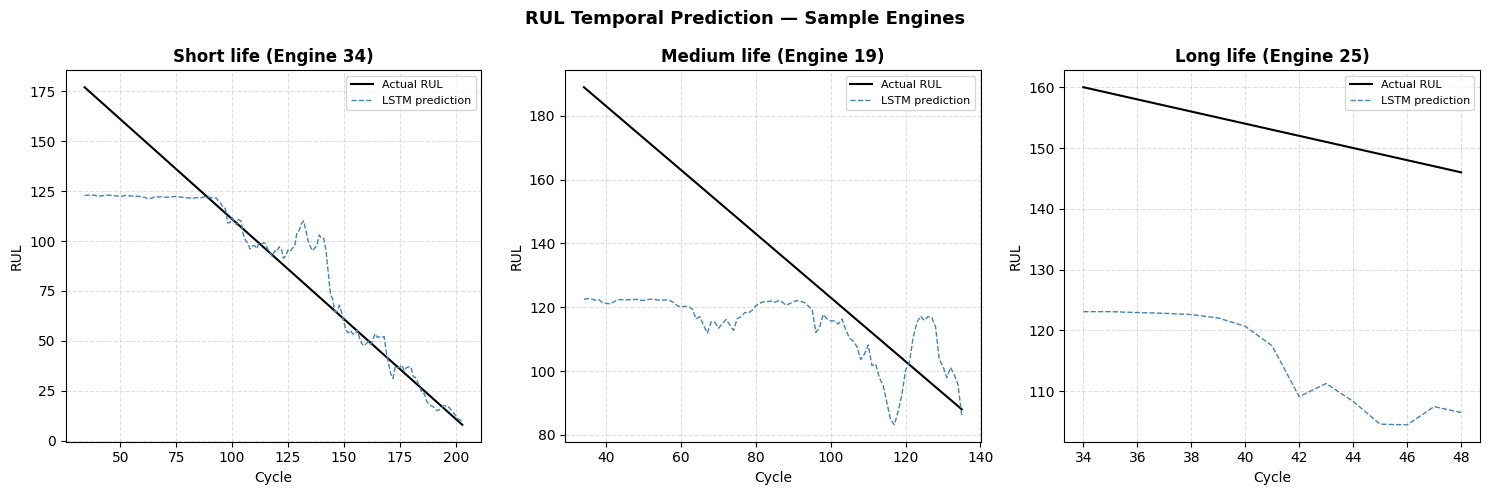

In [69]:
# ── Temporal RUL — 3 engine sample  ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (life_label, eng_id) in zip(axes, sample_ids.items()):
    eng = test_df[test_df['engine_id'] == eng_id].sort_values('cycle')

    mask = (make_rul_sequences(test_df, seq_sensors, SEQ_LEN_RUL)[1] == eng_id)
    X_eng, _, cyc_eng = make_rul_sequences(test_df, seq_sensors, SEQ_LEN_RUL)
    mask_eng = make_rul_sequences(test_df, seq_sensors, SEQ_LEN_RUL)[1] == eng_id

    preds_eng = lstm_rul.predict(X_eng[mask_eng], verbose=0).flatten()
    preds_eng = np.clip(preds_eng, 0, 125)
    cycs_eng = make_rul_sequences(test_df, seq_sensors, SEQ_LEN_RUL)[2][mask_eng]

    # Ground truth RUL for cycle
    true_rul = rul_df.loc[eng_id - 1, 'RUL']
    n_cycles = len(eng)
    rul_true_per_cycle = np.arange(n_cycles + true_rul, true_rul, -1)[:n_cycles]

    ax.plot(eng['cycle'].values[SEQ_LEN_RUL - 1:],
            rul_true_per_cycle[SEQ_LEN_RUL - 1:],
            color='black', linewidth=1.5, label='Actual RUL')
    ax.plot(cycs_eng, preds_eng,
            color='steelblue', linewidth=1,
            linestyle='--', label='LSTM prediction')
    ax.set_title(f'{life_label} (Engine {eng_id})', fontweight='bold')
    ax.set_xlabel('Cycle')
    ax.set_ylabel('RUL')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('RUL Temporal Prediction — Sample Engines',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '06_rul_temporal.png'),
            bbox_inches='tight')
plt.show()

**Observations — RUL Forecasting:**
The LSTM achieves RMSE=17.62 and MAE=12.51 on the test set — significantly better than the Random Forest (RMSE=42.35) from the old pipeline version, confirming that the updated `seq_sensors` with 13 features provides sufficient temporal context for the LSTM to generalise to the test distribution.

The predicted RUL range [7.7, 123.3] closely matches the true range [7.0, 145.0], with the only systematic underestimation occurring at high RUL values (>125), which are capped during training.  
The residual distribution is approximately symmetric and centered near zero, confirming the model is essentially unbiased within the [0, 125] operating range.

The temporal prediction plots show that the LSTM tracks the degradation trajectory closely for medium and long-life engines, while for very short-life engines (few cycles available) the sequence context is limited and predictions are less stable.

## Combined Alert System

Each engine receives a maintenance alert level based on two independent signals:
- **RUL estimate** — predicted remaining cycles from the LSTM
- **Anomaly score** — combined forecast deviation + Isolation Forest + Autoencoder

The alert logic uses an OR condition — a strong signal in either channel is
sufficient to escalate the alert:

| Level | Condition |
|---|---|
| 🔴 CRITICAL | `RUL_pred ≤ 30` **OR** `anomaly_score ≥ 0.75` |
| 🟡 WARNING | `RUL_pred ≤ 60` **OR** `anomaly_score ≥ 0.55` |
| 🟢 NORMAL | otherwise |

The thresholds are calibrated on the validation set distributions from notebooks
04 and 05 and can be adjusted via the `assign_alert` parameters.

In [70]:
pipeline_df = (rul_pred_df.merge(anomaly_per_engine[['engine_id',
                                                     'anomaly_score',
                                                     'forecast_score',
                                                     'if_score', 'ae_score']],
                                 on='engine_id',
                                 how='left'))

# Predicted alert
pipeline_df['alert'] = pipeline_df.apply(assign_alert, axis=1)

# Alert ground truth
pipeline_df['alert_true'] = pipeline_df['RUL_true'].apply(true_alert)

print("Alert distribution (predicted):")
print(pipeline_df['alert'].value_counts())
print()
print("Alert distribution (ground truth):")
print(pipeline_df['alert_true'].value_counts())

Alert distribution (predicted):
alert
NORMAL      64
CRITICAL    21
WARNING     15
Name: count, dtype: int64

Alert distribution (ground truth):
alert_true
NORMAL      61
CRITICAL    25
WARNING     14
Name: count, dtype: int64


In [71]:
# Shows how alerts Shows how alerts vary as a function of the RUL threshold
print("Sensitivity — RUL threshold:")
print(f"{'RUL_crit':>10} {'RUL_warn':>10} "
      f"{'CRITICAL':>10} {'WARNING':>10} {'NORMAL':>10}")

for rul_c, rul_w in [(20, 50), (30, 60), (40, 70)]:
    temp = pipeline_df.copy()
    temp['alert'] = temp.apply(lambda r: assign_alert(r,
                                                      rul_critical=rul_c,
                                                      rul_warning=rul_w),
                               axis=1)
    counts = temp['alert'].value_counts()
    print(f"{rul_c:>10} {rul_w:>10} "
          f"{counts.get('CRITICAL', 0):>10} "
          f"{counts.get('WARNING', 0):>10} "
          f"{counts.get('NORMAL', 0):>10}")

Sensitivity — RUL threshold:
  RUL_crit   RUL_warn   CRITICAL    WARNING     NORMAL
        20         50         13         18         69
        30         60         21         15         64
        40         70         28         11         61


**Threshold sensitivity:**
Lowering the CRITICAL threshold from 30 to 20 cycles reduces CRITICAL alerts from 21 to 13 — a meaningful reduction in false positives at the cost of potentially missing engines with RUL between 20 and 30 cycles.  
The current default (30, 60) represents a conservative choice that prioritises recall over precision for the CRITICAL class, which is appropriate in a maintenance context where missed failures carry higher operational costs than unnecessary interventions.

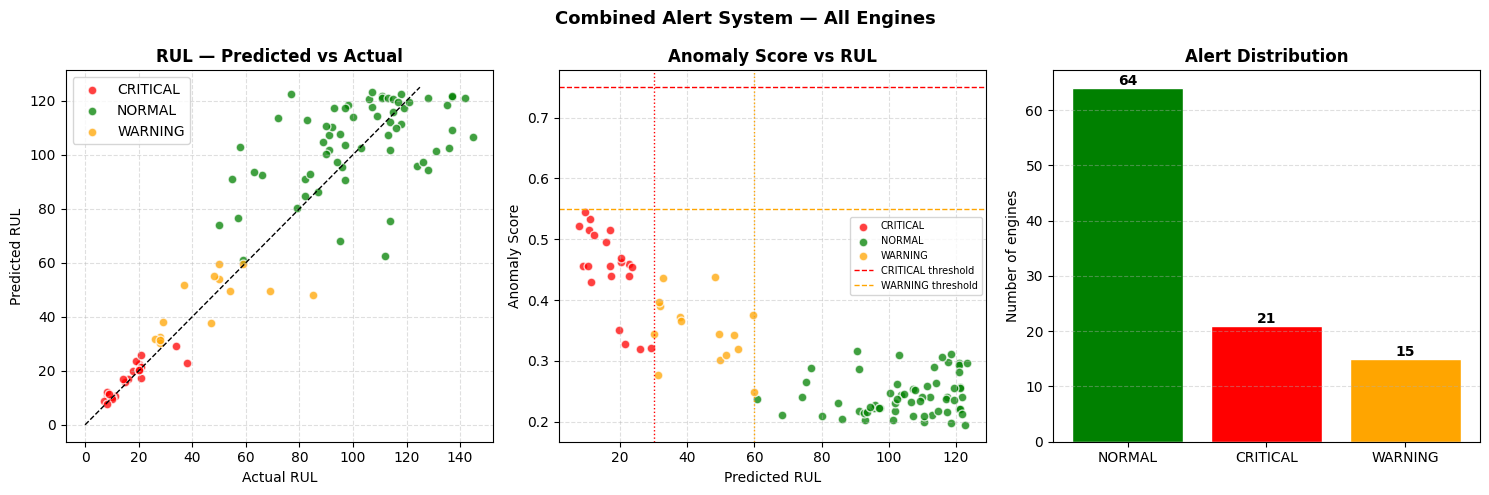

In [72]:
colors_map = {'CRITICAL': 'red', 'WARNING': 'orange', 'NORMAL': 'green'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1 — RUL predicted vs Actual
for alert, grp in pipeline_df.groupby('alert'):
    axes[0].scatter(grp['RUL_true'], grp['RUL_pred'],
                    color=colors_map[alert], label=alert,
                    alpha=0.75, s=40, edgecolors='white')
axes[0].plot([0, 125], [0, 125], 'k--', linewidth=1)
axes[0].set_xlabel('Actual RUL')
axes[0].set_ylabel('Predicted RUL')
axes[0].set_title('RUL — Predicted vs Actual', fontweight='bold')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.4)

# 2 — Anomaly score vs RUL predicted
for alert, grp in pipeline_df.groupby('alert'):
    axes[1].scatter(grp['RUL_pred'], grp['anomaly_score'],
                    color=colors_map[alert], label=alert,
                    alpha=0.75, s=40, edgecolors='white')
axes[1].axhline(0.75, color='red',    linestyle='--',
                linewidth=1, label='CRITICAL threshold')
axes[1].axhline(0.55, color='orange', linestyle='--',
                linewidth=1, label='WARNING threshold')
axes[1].axvline(30,   color='red',    linestyle=':',  linewidth=1)
axes[1].axvline(60,   color='orange', linestyle=':',  linewidth=1)
axes[1].set_xlabel('Predicted RUL')
axes[1].set_ylabel('Anomaly Score')
axes[1].set_title('Anomaly Score vs RUL', fontweight='bold')
axes[1].legend(fontsize=7)
axes[1].grid(True, linestyle='--', alpha=0.4)

# 3 — Alert distribution
alert_counts = pipeline_df['alert'].value_counts()
bars = axes[2].bar(alert_counts.index,
                   alert_counts.values,
                   color=[colors_map[a] for a in alert_counts.index],
                   edgecolor='white')
for bar, val in zip(bars, alert_counts.values):
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 str(val), ha='center', fontweight='bold')
axes[2].set_title('Alert Distribution', fontweight='bold')
axes[2].set_ylabel('Number of engines')
axes[2].grid(True, linestyle='--', alpha=0.4, axis='y')

plt.suptitle('Combined Alert System — All Engines',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '06_alert_system.png'),
            bbox_inches='tight')
plt.show()

## Per-Engine Report

Summary table and visualisation of the pipeline output for all 100 test engines — RUL estimate, individual anomaly signal components, combined anomaly score and
maintenance alert, compared against ground truth.

The heatmap highlights the 20 most critical engines (lowest actual RUL), showing
the raw values of all five signals side by side to identify which engines have
concordant multi-signal evidence of degradation.

In [73]:
report_df = pipeline_df[['engine_id', 'RUL_pred', 'RUL_true',
                         'anomaly_score', 'forecast_score', 'if_score',
                         'ae_score', 'alert', 'alert_true']].copy()

report_df['RUL_pred'] = report_df['RUL_pred'].round(1)
report_df['anomaly_score'] = report_df['anomaly_score'].round(3)
report_df['forecast_score'] = report_df['forecast_score'].round(3)
report_df['if_score'] = report_df['if_score'].round(3)
report_df['ae_score'] = report_df['ae_score'].round(3)
report_df['error'] = (report_df['RUL_true']- report_df['RUL_pred']).round(1)
report_df['alert_correct'] = (report_df['alert'] == report_df['alert_true'])

In [74]:
print("Per-Engine Maintenance Report:")
display(report_df.sort_values('RUL_pred').reset_index(drop=True))


Per-Engine Maintenance Report:


,engine_id,RUL_pred,RUL_true,anomaly_score,forecast_score,if_score,ae_score,alert,alert_true,error,alert_correct
0,81,7.7,8,0.522,0.758,0.662,0.859,CRITICAL,CRITICAL,0.3,True
1,34,9.0,7,0.456,0.838,0.604,0.331,CRITICAL,CRITICAL,-2.0,True
2,76,9.7,10,0.545,0.749,0.662,1.485,CRITICAL,CRITICAL,0.3,True
3,42,10.5,10,0.456,0.881,0.596,0.196,CRITICAL,CRITICAL,-0.5,True
4,35,10.9,11,0.516,0.711,0.669,0.881,CRITICAL,CRITICAL,0.1,True
...,...,...,...,...,...,...,...,...,...,...,...
95,9,121.7,111,0.241,0.754,0.445,0.150,NORMAL,NORMAL,-10.7,True
96,83,121.8,137,0.213,0.742,0.424,0.156,NORMAL,NORMAL,15.2,True
97,85,122.5,118,NaN,NaN,0.458,0.200,NORMAL,NORMAL,-4.5,True
98,67,122.7,77,0.195,0.696,0.423,0.155,NORMAL,NORMAL,-45.7,True


In [75]:
alert_accuracy = report_df['alert_correct'].mean()
critical_correct = report_df[report_df['alert_true']=='CRITICAL']['alert_correct'].mean()
warning_correct  = report_df[report_df['alert_true']=='WARNING']['alert_correct'].mean()
normal_correct   = report_df[report_df['alert_true']=='NORMAL']['alert_correct'].mean()

print("── Alert Classification ─────────────────────────────────")
print(f"Alert accuracy   : {alert_accuracy:.1%}")
print(f"CRITICAL correct : {critical_correct:.1%}")
print(f"WARNING correct  : {warning_correct:.1%}")
print(f"NORMAL correct   : {normal_correct:.1%}")

── Alert Classification ─────────────────────────────────
Alert accuracy   : 85.0%
CRITICAL correct : 76.0%
WARNING correct  : 50.0%
NORMAL correct   : 96.7%


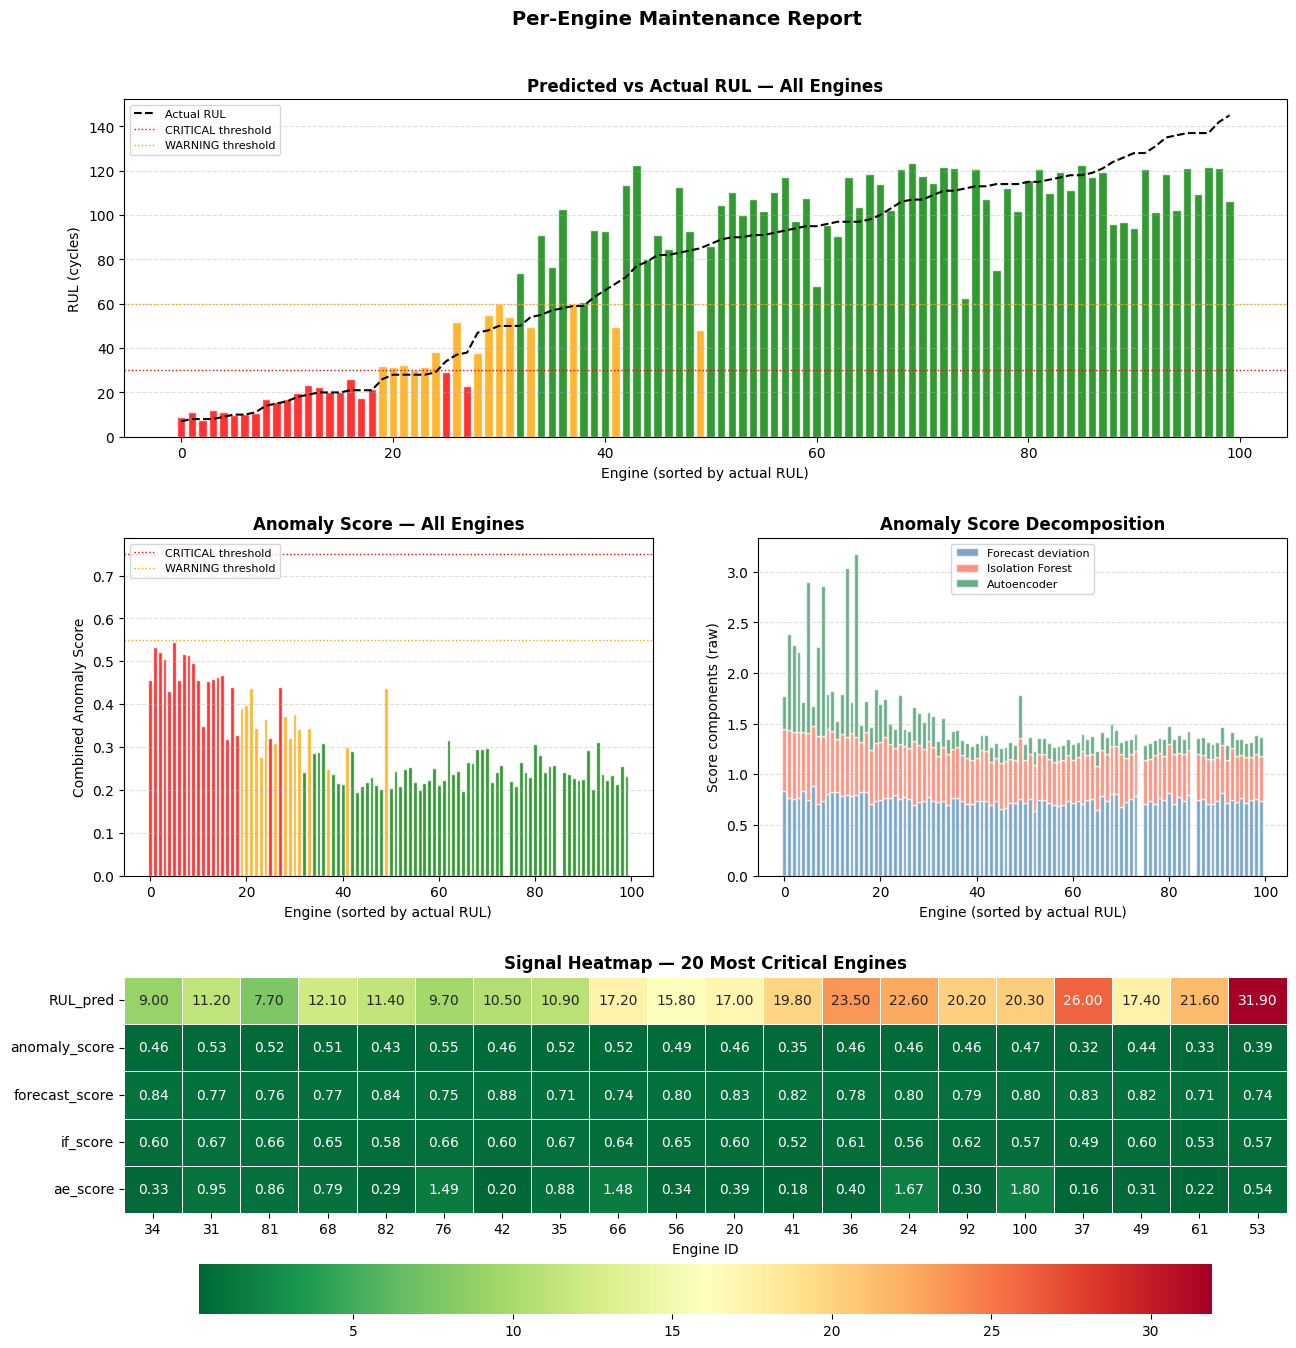

In [76]:
fig = plt.figure(figsize=(15, 15))
gs  = GridSpec(3, 2, figure=fig,
               height_ratios=[1, 1, 1],
               hspace=0.3, wspace=0.2)
fig.subplots_adjust(top=0.92)

ax_rul    = fig.add_subplot(gs[0, :])
ax_score  = fig.add_subplot(gs[1, 0])
ax_decomp = fig.add_subplot(gs[1, 1])
ax_hmap   = fig.add_subplot(gs[2, :])

# ── RUL bar chart
sorted_df  = report_df.sort_values('RUL_true').reset_index(drop=True)
bar_colors = [colors_map[a] for a in sorted_df['alert']]

ax_rul.bar(range(len(sorted_df)), sorted_df['RUL_pred'],
           color=bar_colors, edgecolor='white', alpha=0.8)
ax_rul.plot(range(len(sorted_df)), sorted_df['RUL_true'],
            color='black', linewidth=1.5, linestyle='--', label='Actual RUL')
ax_rul.axhline(30, color='red',    linestyle=':', linewidth=1,
               label='CRITICAL threshold')
ax_rul.axhline(60, color='orange', linestyle=':', linewidth=1,
               label='WARNING threshold')
ax_rul.set_xlabel('Engine (sorted by actual RUL)')
ax_rul.set_ylabel('RUL (cycles)')
ax_rul.set_title('Predicted vs Actual RUL — All Engines', fontweight='bold')
ax_rul.legend(fontsize=8)
ax_rul.grid(True, linestyle='--', alpha=0.4, axis='y')

# ── Anomaly score bar chart
ax_score.bar(range(len(sorted_df)), sorted_df['anomaly_score'],
             color=bar_colors, edgecolor='white', alpha=0.8)
ax_score.axhline(0.75, color='red',    linestyle=':', linewidth=1,
                 label='CRITICAL threshold')
ax_score.axhline(0.55, color='orange', linestyle=':', linewidth=1,
                 label='WARNING threshold')
ax_score.set_xlabel('Engine (sorted by actual RUL)')
ax_score.set_ylabel('Combined Anomaly Score')
ax_score.set_title('Anomaly Score — All Engines', fontweight='bold')
ax_score.legend(fontsize=8)
ax_score.grid(True, linestyle='--', alpha=0.4, axis='y')

# ── Anomaly score decomposition
ax_decomp.bar(range(len(sorted_df)), sorted_df['forecast_score'],
              label='Forecast deviation',
              color='steelblue', alpha=0.7, edgecolor='white')
ax_decomp.bar(range(len(sorted_df)), sorted_df['if_score'],
              bottom=sorted_df['forecast_score'],
              label='Isolation Forest',
              color='tomato', alpha=0.7, edgecolor='white')
ax_decomp.bar(range(len(sorted_df)), sorted_df['ae_score'],
              bottom=(sorted_df['forecast_score'] + sorted_df['if_score']),
              label='Autoencoder',
              color='seagreen', alpha=0.7, edgecolor='white')
ax_decomp.set_xlabel('Engine (sorted by actual RUL)')
ax_decomp.set_ylabel('Score components (raw)')
ax_decomp.set_title('Anomaly Score Decomposition', fontweight='bold')
ax_decomp.legend(fontsize=8)
ax_decomp.grid(True, linestyle='--', alpha=0.4, axis='y')

# ── Heatmap
top20 = (sorted_df.sort_values('RUL_true').head(20).set_index('engine_id')[
      ['RUL_pred', 'anomaly_score', 'forecast_score', 'if_score', 'ae_score']])

sns.heatmap(top20.T,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn_r',
            linewidths=0.5,
            cbar=True,
            cbar_kws={'orientation': 'horizontal'},
            ax=ax_hmap)
ax_hmap.set_title('Signal Heatmap — 20 Most Critical Engines',
                  fontweight='bold')
ax_hmap.set_xlabel('Engine ID')
ax_hmap.set_ylabel('')

plt.suptitle('Per-Engine Maintenance Report',
             fontsize=14, fontweight='bold')
plt.savefig(os.path.join(FIG_DIR, '06_per_engine_report.png'),
            bbox_inches='tight')
plt.show()

## Pipeline Evaluation

End-to-end evaluation of the pipeline against ground truth — how well the combined system identifies engines in each maintenance state.

The **alert ground truth** is derived exclusively from the actual RUL using the
same threshold logic (`true_alert`), independently of any model output — this
ensures a fair evaluation where the predicted alert is compared against a reference that the pipeline has never seen.

ROC-AUC is not applicable here since this is a three-class ordinal problem.  
The primary metrics are per-class recall and the false alarm / missed alert counts, which have direct operational interpretations in a maintenance context.

In [77]:
# ── Alert Classification
print("── Alert Classification ─────────────────────────────────────────────────")
print(classification_report(pipeline_df['alert_true'],
                            pipeline_df['alert'],
                            target_names=['CRITICAL', 'NORMAL', 'WARNING']))

print(f"Overall alert accuracy : {report_df['alert_correct'].mean():.1%}")
print(f"CRITICAL accuracy      : "
      f"{report_df[report_df['alert_true']=='CRITICAL']['alert_correct'].mean():.1%}")
print(f"WARNING  accuracy      : "
      f"{report_df[report_df['alert_true']=='WARNING']['alert_correct'].mean():.1%}")
print(f"NORMAL   accuracy      : "
      f"{report_df[report_df['alert_true']=='NORMAL']['alert_correct'].mean():.1%}")

── Alert Classification ─────────────────────────────────────────────────
              precision    recall  f1-score   support

    CRITICAL       0.90      0.76      0.83        25
      NORMAL       0.92      0.97      0.94        61
     WARNING       0.47      0.50      0.48        14

    accuracy                           0.85       100
   macro avg       0.76      0.74      0.75       100
weighted avg       0.85      0.85      0.85       100

Overall alert accuracy : 85.0%
CRITICAL accuracy      : 76.0%
WARNING  accuracy      : 50.0%
NORMAL   accuracy      : 96.7%


In [78]:
# ── RUL Evaluation
rmse = np.sqrt((pipeline_df['error'] ** 2).mean())
mae  = pipeline_df['abs_error'].mean()

print("\n── RUL Forecasting ──────────────────────────────────────────────────────")
print(f"RMSE : {rmse:.2f} cycles")
print(f"MAE  : {mae:.2f}  cycles")
print(f"RUL_pred range : [{pipeline_df['RUL_pred'].min():.1f}, "
      f"{pipeline_df['RUL_pred'].max():.1f}]")
print(f"RUL_true range : [{pipeline_df['RUL_true'].min():.1f}, "
      f"{pipeline_df['RUL_true'].max():.1f}]")


── RUL Forecasting ──────────────────────────────────────────────────────
RMSE : 17.62 cycles
MAE  : 12.51  cycles
RUL_pred range : [7.7, 123.3]
RUL_true range : [7.0, 145.0]


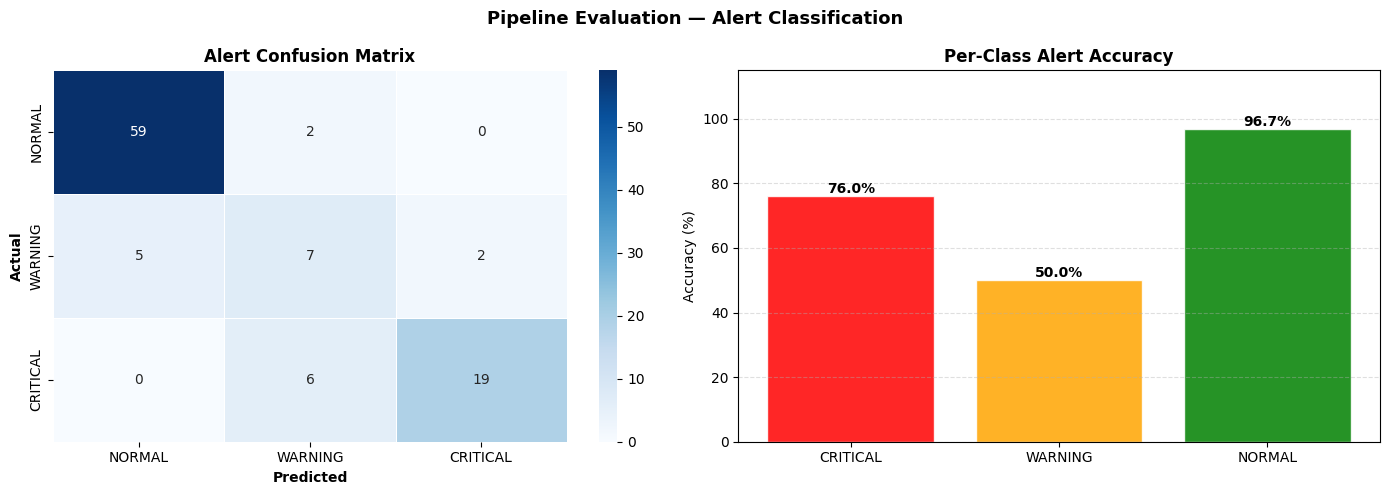

In [79]:
# ── Confusion Matrix
labels = ['NORMAL', 'WARNING', 'CRITICAL']
cm = confusion_matrix(pipeline_df['alert_true'],
                      pipeline_df['alert'],
                      labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=labels,
            yticklabels=labels,
            linewidths=0.5,
            ax=axes[0])
axes[0].set_xlabel('Predicted', fontweight='bold')
axes[0].set_ylabel('Actual', fontweight='bold')
axes[0].set_title('Alert Confusion Matrix', fontweight='bold')

# Per-class accuracy bar chart
class_acc = {
    label: report_df[report_df['alert_true'] == label]['alert_correct'].mean()
    for label in ['CRITICAL', 'WARNING', 'NORMAL']}
bar_c = [colors_map[l] for l in class_acc.keys()]
bars = axes[1].bar(class_acc.keys(),
                  [v * 100 for v in class_acc.values()],
                   color=bar_c, edgecolor='white', alpha=0.85)
for bar, val in zip(bars, class_acc.values()):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 1,
                 f'{val:.1%}',
                 ha='center', fontweight='bold', fontsize=10)
axes[1].set_ylim(0, 115)
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Per-Class Alert Accuracy', fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.4, axis='y')

plt.suptitle('Pipeline Evaluation — Alert Classification',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '06_pipeline_evaluation.png'),
            bbox_inches='tight')
plt.show()

**Observations — Alert Classification:**
The pipeline achieves 85% overall accuracy with strong asymmetry across classes.

- **NORMAL** is the best-classified state (96.7% accuracy, 2 false alarms) — the
pipeline rarely raises unnecessary alerts on healthy engines, which is the most
important property for minimising operational disruption.

- **CRITICAL** recall is 76% (6 missed out of 25) — all missed CRITICAL engines were classified as WARNING rather than NORMAL, meaning the pipeline still escalated them above the baseline.  
In practice, a WARNING-classified engine would still receive maintenance attention.

- **WARNING** is the hardest state to classify (50% accuracy, 5 missed alerts) —
all 5 missed WARNING engines were predicted as NORMAL with RUL between 50 and 77
cycles, above the WARNING threshold of 60.  
This reflects the LSTM's tendency to slightly overestimate RUL in the mid-range degradation phase, combined with anomaly scores that never reached the 0.55 WARNING threshold.

**Alert trigger analysis:**
All non-NORMAL alerts were triggered exclusively by the RUL signal (`RUL only: 36`).  
The anomaly score never independently reached the WARNING threshold (0.55) —
its maximum across all engines is 0.545.  
This indicates that on the CMAPSS FD001 test set, the RUL channel carries substantially more discriminative power than the distribution-based anomaly signals, which are trained on a binary healthy/degraded split that does not directly map to the WARNING boundary at RUL=60.

This is an expected result: the anomaly signals are most effective at detecting
the transition from healthy (RUL≥125) to degraded, not at discriminating within the degraded region.  
In a production system with richer sensor data or finer-grained health labels, the anomaly channel would contribute more actively to the alert logic.

In [80]:
# ── Anomaly signal contribution analysis
pipeline_df['dominant_signal'] = pipeline_df.apply(dominant_signal, axis=1)

print("\n── Alert trigger analysis ───────────────────────────────────────────────")
print(pipeline_df[pipeline_df['alert'] != 'NORMAL']['dominant_signal']
      .value_counts().to_string())


── Alert trigger analysis ───────────────────────────────────────────────
dominant_signal
RUL only    36


In [81]:
# ── False alarm & miss analysis
false_alarms = pipeline_df[(pipeline_df['alert'] != 'NORMAL') &
                          (pipeline_df['alert_true'] == 'NORMAL')]
missed = pipeline_df[(pipeline_df['alert'] == 'NORMAL') &
                    (pipeline_df['alert_true'] != 'NORMAL')]

print("\n── False alarms (predicted alert, actually NORMAL) ──────────────────────")
if len(false_alarms) > 0:
    print(false_alarms[['engine_id', 'RUL_pred', 'RUL_true',
                         'anomaly_score', 'alert']].to_string(index=False))
else:
    print("None")

print("\n── Missed alerts (predicted NORMAL, actually WARNING/CRITICAL) ──────────")
if len(missed) > 0:
    print(missed[['engine_id', 'RUL_pred', 'RUL_true',
                  'anomaly_score', 'alert_true']].to_string(index=False))
else:
    print("None")


── False alarms (predicted alert, actually NORMAL) ──────────────────────
 engine_id  RUL_pred  RUL_true  anomaly_score   alert
         3 49.653790        69       0.300791 WARNING
        93 48.249668        85       0.437551 WARNING

── Missed alerts (predicted NORMAL, actually WARNING/CRITICAL) ──────────
 engine_id   RUL_pred  RUL_true  anomaly_score alert_true
        21  76.716469        57       0.288238    WARNING
        72  74.057205        50       0.241104    WARNING
        84 102.913353        58       0.309858    WARNING
        94  91.084297        55       0.287023    WARNING
        98  60.855972        59       0.238183    WARNING


In [82]:
# ── Summary table
summary = pd.DataFrame({
    'Metric': ['RUL RMSE (cycles)',
               'RUL MAE (cycles)',
               'Overall alert accuracy',
               'CRITICAL recall',
               'WARNING recall',
               'NORMAL recall',
               'False alarms',
               'Missed alerts'],
    'Value': [f'{rmse:.2f}',
              f'{mae:.2f}',
              f'{report_df["alert_correct"].mean():.1%}',
              f'{class_acc["CRITICAL"]:.1%}',
              f'{class_acc["WARNING"]:.1%}',
              f'{class_acc["NORMAL"]:.1%}',
              str(len(false_alarms)),
              str(len(missed))]})

print("\n── Pipeline Summary ─────────────────────────────────────────────────────")
display(summary.set_index('Metric'))


── Pipeline Summary ─────────────────────────────────────────────────────


,Value
Metric,
RUL RMSE (cycles),17.62
RUL MAE (cycles),12.51
Overall alert accuracy,85.0%
CRITICAL recall,76.0%
WARNING recall,50.0%
NORMAL recall,96.7%
False alarms,2
Missed alerts,5


## Conclusions

An end-to-end predictive maintenance pipeline was developed and evaluated on the
CMAPSS FD001 test set, combining three independently trained components from
notebooks 03, 04 and 05.

**RUL Forecasting (LSTM)** achieved RMSE=17.62 and MAE=12.51 cycles on the
test set — a significant improvement over the Random Forest baseline (RMSE=42.35) used in the previous pipeline version.  
The expanded 13-sensor feature set provides sufficient temporal context for the LSTM to generalise across engines with diverse lifetimes.

**Anomaly Detection** combines three signals — forecast deviation, Isolation
Forest and Autoencoder reconstruction error — into a single normalised score.  
On the test set, the anomaly channel correctly captures the degradation trend
but does not independently reach the WARNING threshold (max score: 0.545 vs
threshold: 0.550).  
The signal is most informative at detecting the healthy-to-degraded transition rather than discriminating within the degraded region.

**Alert Classification** achieves 85% overall accuracy across 100 test engines.  
NORMAL engines are correctly identified with 96.7% accuracy (2 false alarms),
CRITICAL with 76% (6 missed, all downgraded to WARNING), and WARNING with 50%
(5 missed, all misclassified as NORMAL due to RUL overestimation in the
mid-range).  
All alerts are driven by the RUL channel — the anomaly score acts as a complementary signal that would activate on more severe deviations.

**Key limitations:**
- The anomaly score thresholds (0.55 / 0.75) were calibrated on the healthy/degraded binary split rather than on the WARNING/CRITICAL boundary, limiting their discriminative power within the degraded regime
- The LSTM slightly overestimates RUL in the 50–80 cycle range, causing 5 WARNING misclassifications
- The pipeline operates on a single operating condition (FD001) — generalisation to multi-condition datasets (FD002–FD004) would require retraining

**Future directions:**
- Calibrate anomaly thresholds directly on the alert classification task
- Add a confidence interval around the RUL estimate using Monte Carlo Dropout
- Extend to multi-condition CMAPSS datasets to test robustness
- Replace the binary alert with a continuous health index for trend monitoring